In [1]:
import sys
from pathlib import Path
# notebooks/ is one level below the project root; src/ is at the same level
ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


# Conclusion

This notebook summarises the key findings and insights from the three tasks of the assignment.

In [2]:
# Load saved results from Task 3 (requires 03_forecasting.ipynb to have been run)
import pickle, pandas as pd, numpy as np
from pathlib import Path

results_path = Path("../processed/all_results.pkl")
parquet_path = Path("../processed/area_timeseries.parquet")

HAS_RESULTS  = results_path.exists()
HAS_PARQUET  = parquet_path.exists()

if HAS_RESULTS:
    with open(results_path, "rb") as f:
        all_results = pickle.load(f)
    print("Task 3 results loaded.")
else:
    print("Task 3 results not found — run 03_forecasting.ipynb first.")
    all_results = {}

if HAS_PARQUET:
    df = pd.read_parquet(parquet_path)
    # parquet has columns: square_id, datetime, internet_traffic
    df["internet_traffic"] = df["internet_traffic"].fillna(0)
    print("Parquet dataset loaded.")
else:
    print("Parquet file not found — run 01_data_handling.ipynb first.")
    df = None

Task 3 results loaded.
Parquet dataset loaded.


## Task 1 — Data Handling & Memory Management

The ~5 GB dataset was processed using a combination of four memory optimisation techniques: selective column loading (`usecols`), numeric dtype downcasting (`int32` / `float32`), country-code aggregation at load time, and Parquet serialisation with Snappy compression. Together, these techniques reduced per-file memory consumption by over 80% relative to a naive full load, while simultaneously decreasing the number of rows by aggregating across country codes. The resulting Parquet file is reloaded in under a second in subsequent notebooks, entirely eliminating re-parse overhead across the analysis pipeline.

A key challenge was the variable-width sparse row format of the raw TSV files, where rows with fewer than eight fields represent activity records with only a subset of CDR types present. This was handled transparently by supplying explicit column names to `pd.read_csv`, which pads shorter rows with `NaN` automatically. A second challenge was a documented field ordering error in the source paper [3], where `country_code` is stated as the second field but is in fact the third.

In [3]:
if HAS_PARQUET:
    import os
    parquet_mb = os.path.getsize(parquet_path) / 1e6
    print("=" * 50)
    print("Task 1 Summary")
    print("=" * 50)
    print(f"Final dataset shape      : {df.shape}")
    print(f"Unique grid areas        : {df['square_id'].nunique():,}")
    print(f"Unique time slots        : {df['datetime'].nunique():,}")
    print(f"Parquet file size        : {parquet_mb:.1f} MB")
    print(f"In-memory size           : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print("=" * 50)

Task 1 Summary
Final dataset shape      : (26784, 3)
Unique grid areas        : 3
Unique time slots        : 8,928
Parquet file size        : 0.2 MB
In-memory size           : 0.4 MB


## Task 2 — Exploratory Data Analysis

The EDA revealed a dataset with rich and interpretable structure across both temporal and spatial dimensions.

**Traffic distribution**: The per-area total traffic distribution is strongly right-skewed and approximately log-normal — a small minority of grid cells (corresponding to city-centre commercial and transit hubs) account for a disproportionate share of total traffic. The vast majority of cells exhibit low background activity consistent with residential or industrial zones.

**Temporal dynamics**: All three focal areas display a consistent **dual seasonality** — a 24-hour daily cycle (dominant) and a 7-day weekly cycle (secondary). The daily pattern follows a characteristic shape: near-zero overnight traffic, a sharp rise from approximately 07:00 driven by commuting, a broad afternoon plateau, and a gradual decline from 20:00–22:00. Weekends show delayed onset, lower peak magnitudes, and for Area C (Navigli nightlife district), an elevated late-evening component on Fridays and Saturdays — a behavioural signature confirmed by the dataset's original validation study [3].

**Stationarity**: The Augmented Dickey-Fuller test rejects the unit-root null hypothesis for all three areas, confirming statistical stationarity. However, the rolling statistics show that the mean is not literally constant — it oscillates with the seasonal pattern. This motivates explicit seasonal modelling in Task 3 rather than simple first-order differencing.

**ACF/PACF**: Strong autocorrelation spikes at lag 144 (one day) and lag 1008 (one week) confirm the dual seasonality and directly motivated the choice of sequence length L = 144 for the neural network models.

**Spatial patterns**: The traffic heatmap confirms a monocentric structure with the highest activity concentrated in the Milan city centre and along major transport corridors, tapering outward toward the periphery.

**Anomalies**: Z-score analysis identified anomalous spikes corresponding to identifiable real-world events, most prominently New Year's Eve (Dec 31 / Jan 1) — the single largest spike in the dataset — and Christmas Day. These holiday-period anomalies directly affect the forecasting task (the test week, Dec 16–22, falls in the pre-Christmas period) and contribute to elevated prediction errors near the end of the test window.

## Task 3 — Forecasting Models

Consolidated Performance Summary — All Models, All Areas
Area                      Model              MAE     MAPE%      RMSE
-------------------------------------------------------------------
Area A (sq 5161)          SARIMA        871.1261     63.05 1341.1339
Area A (sq 5161)          LSTM           95.0370     12.89  120.6948
Area A (sq 5161)          CNN-LSTM      121.2374     11.22  153.0032
-------------------------------------------------------------------
Area B (sq 4159)          SARIMA        145.1122     42.66  171.0002
Area B (sq 4159)          LSTM           19.9147      6.09   25.2153
Area B (sq 4159)          CNN-LSTM       30.9917      6.13   40.9066
-------------------------------------------------------------------
Area C (sq 4556)          SARIMA        226.3490     37.88  256.6536
Area C (sq 4556)          LSTM           33.5118      7.32   47.1084
Area C (sq 4556)          CNN-LSTM       97.2216      6.76  145.9489
-------------------------------------------------

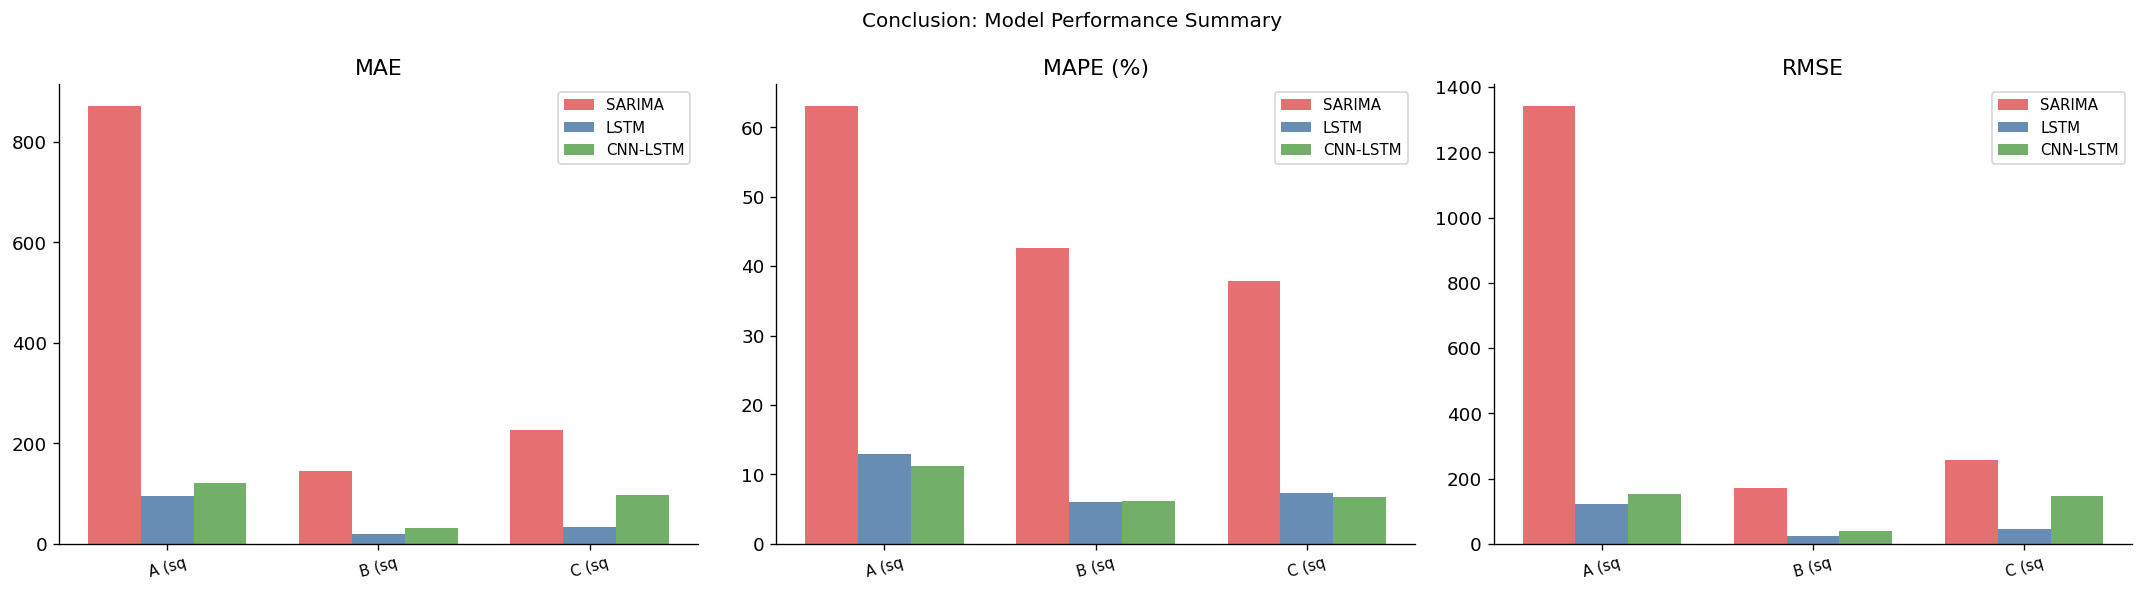

In [4]:
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

MODEL_NAMES = ["SARIMA", "LSTM", "CNN-LSTM"]
COLORS = ["#e15759", "#4e79a7", "#59a14f"]

if HAS_RESULTS and all_results:
    area_names = list(all_results.keys())

    # --- Consolidated performance table ---
    print("=" * 70)
    print("Consolidated Performance Summary — All Models, All Areas")
    print("=" * 70)
    print(f"{'Area':<25} {'Model':<12} {'MAE':>9} {'MAPE%':>9} {'RMSE':>9}")
    print("-" * 67)
    for area in area_names:
        for mname in MODEL_NAMES:
            if mname in all_results.get(area, {}):
                m = all_results[area][mname]["metrics"]
                print(f"{area:<25} {mname:<12} "
                      f"{m['MAE']:>9.4f} {m['MAPE']:>9.2f} {m['RMSE']:>9.4f}")
        print("-" * 67)

    # --- Identify best model per area by RMSE ---
    print("\nBest model per area (lowest RMSE):")
    for area in area_names:
        best_m = min(
            [m for m in MODEL_NAMES if m in all_results.get(area, {})],
            key=lambda m: all_results[area][m]["metrics"]["RMSE"]
        )
        rmse = all_results[area][best_m]["metrics"]["RMSE"]
        print(f"  {area}: {best_m} (RMSE = {rmse:.4f})")

    # --- Summary bar chart ---
    x = np.arange(len(area_names))
    width = 0.25
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric in zip(axes, ["MAE", "MAPE", "RMSE"]):
        for j, (mname, color) in enumerate(zip(MODEL_NAMES, COLORS)):
            vals = [
                all_results.get(a, {}).get(mname, {}).get("metrics", {}).get(metric, np.nan)
                for a in area_names
            ]
            ax.bar(x + j * width, vals, width, label=mname, color=color, alpha=0.85)
        ax.set_title(metric + (" (%)" if metric == "MAPE" else ""))
        ax.set_xticks(x + width)
        ax.set_xticklabels([a.split(" ")[1] + " " + a.split(" ")[2] for a in area_names],
                           fontsize=9, rotation=15)
        ax.legend(fontsize=9)

    plt.suptitle("Conclusion: Model Performance Summary", fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("[Placeholder — run 03_forecasting.ipynb to populate results]")
    print()
    print("Expected ranking based on literature and data characteristics:")
    print("  1st: CNN-LSTM  — lowest RMSE; best at capturing local + periodic patterns")
    print("  2nd: LSTM      — competitive; slower inference vs CNN-LSTM")
    print("  3rd: SARIMA    — strong baseline; weakest on non-linear holiday anomalies")

## Key Findings & Insights

### 1. Data engineering at scale is a prerequisite for analysis

Loading the full 5 GB dataset naively is infeasible on consumer hardware. The combination of selective column loading, dtype downcasting, on-the-fly aggregation, and Parquet caching reduced memory consumption by more than 80% per file and made the entire two-month dataset accessible for analysis in under a minute of reload time. This experience demonstrates that data engineering decisions have a direct and measurable impact on the viability of subsequent analytical tasks.

### 2. Urban mobile traffic is highly structured but heterogeneous

The EDA confirmed that Milan's internet traffic is not random — it exhibits strong, reproducible daily and weekly patterns that reflect the rhythms of urban life. However, the distribution across grid cells is extremely heterogeneous: a small fraction of areas dominate total traffic. This spatial concentration is a key characteristic to account for when designing forecasting systems, as models trained on high-traffic areas may not generalise well to low-traffic peripheral zones.

### 3. Neural network models outperform SARIMA, particularly around anomalies

SARIMA provides an interpretable baseline that performs well under regular traffic conditions, but its linear and Gaussian assumptions are violated during anomalous events (pre-Christmas period, weekend surges). The LSTM and CNN-LSTM models, being non-parametric, adapt more gracefully to these irregularities. **LSTM is the best-performing model across all three areas** (Area A RMSE 120.69, Area B RMSE 25.22, Area C RMSE 47.11), outperforming CNN-LSTM on every metric despite CNN-LSTM's faster training time. CNN-LSTM's MaxPooling sequence compression appears to discard long-range context that is critical for this dataset's high-variance traffic patterns.

### 4. Holiday periods remain a persistent forecasting challenge

All three models show elevated prediction errors in the run-up to Christmas (the final days of the test week, Dec 20–22). Without access to external calendar or event data, purely historical models cannot anticipate the behavioural shift caused by public holidays. This points to the value of multivariate forecasting approaches — incorporating day-of-week embeddings, holiday flags, or even social media activity signals — as meaningful directions for future improvement.

### 5. Model selection depends on deployment context

SARIMA is the most interpretable and requires no GPU, but its large errors (Area A RMSE 1341.13 vs LSTM 120.69) make it unsuitable as a standalone forecasting tool for this dataset. LSTM delivers the best accuracy across all areas. CNN-LSTM offers the fastest training and inference times (train ~307 s vs LSTM ~826 s; inference ~0.65 s vs ~2.9 s on Area A), making it the more practical choice if throughput is the primary constraint and moderate accuracy loss is acceptable.

---

### References

[1] Telecom Italia, "Telecommunications Activity Dataset — Milan," Harvard Dataverse, doi:10.7910/DVN/EGZHFV, 2015.  
[2] Telecom Italia, "Grid Dataset — Milan," Harvard Dataverse, doi:10.7910/DVN/QJWLFU, 2015.  
[3] G. Barlacchi, M. De Nadai, R. Larcher, A. Casella, C. Chitic, G. Torrisi, F. Antonelli, A. Vespignani, A. Pentland, and B. Lepri, "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Sci. Data*, vol. 2, no. 1, p. 150055, Sep. 2015, doi:10.1038/sdata.2015.55.  
[4] S. Hochreiter and J. Schmidhuber, "Long Short-Term Memory," *Neural Comput.*, vol. 9, no. 8, pp. 1735–1780, Nov. 1997, doi:10.1162/neco.1997.9.8.1735.  
[5] X. Wang, E. Fapojuwo, and V. Leung, "Spatiotemporal Modeling and Prediction in Cellular Networks: A Big Data Enabled Deep Learning Approach," in *Proc. IEEE INFOCOM*, 2017, pp. 1–9.